## Imports + Load model:

In [1]:
!pip install transformers sentencepiece -q

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (
    f1_score, classification_report,
    precision_recall_curve, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# Load model
HF_REPO   = 'sourabh5500/hate-speech-muril'
tokenizer = AutoTokenizer.from_pretrained(HF_REPO)
model     = AutoModelForSequenceClassification.from_pretrained(HF_REPO)
model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)
print(f"✅ Model loaded on {device}")

config.json:   0%|          | 0.00/815 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/346 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Invalid model-index. Not loading eval results into CardData.


model.safetensors:   0%|          | 0.00/950M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Model loaded on cuda


## Load test data + get probabilities:

In [2]:
BASE    = '/kaggle/input/datasets/sourabhsaxena/hatespeech01'
test_df = pd.read_csv(f'{BASE}/test.csv')
test_df['text'] = test_df['text'].fillna('').astype(str)

def get_probabilities(texts, batch_size=64):
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc   = tokenizer(
            batch, max_length=128,
            padding=True, truncation=True,
            return_tensors='pt'
        ).to(device)
        with torch.no_grad():
            logits = model(**enc).logits
            probs  = torch.softmax(logits, dim=1)
        all_probs.extend(probs.cpu().numpy())
    return np.array(all_probs)

print("Getting probabilities...")
probs          = get_probabilities(test_df['text'].tolist())
test_df['prob_NOT'] = probs[:, 0]
test_df['prob_HOF'] = probs[:, 1]
y_true              = test_df['label'].values

print(f"✅ Done — {len(test_df)} samples")

Getting probabilities...
✅ Done — 5907 samples


## Sweep thresholds:

In [3]:
# Cell 3 — Find optimal threshold
# Sweep from 0.3 to 0.7 and measure all metrics

thresholds = np.arange(0.30, 0.71, 0.01)
results    = []

for t in thresholds:
    y_pred     = (test_df['prob_HOF'] >= t).astype(int)
    macro_f1   = f1_score(y_true, y_pred, average='macro')
    hof_f1     = f1_score(y_true, y_pred, pos_label=1, average='binary')
    hof_recall = f1_score(y_true, y_pred, pos_label=1, average='binary',
                          labels=[1])
    
    from sklearn.metrics import recall_score, precision_score
    hof_recall    = recall_score(y_true, y_pred, pos_label=1)
    hof_precision = precision_score(y_true, y_pred, pos_label=1)
    fn_rate       = ((y_pred == 0) & (y_true == 1)).sum() / (y_true == 1).sum()
    fp_rate       = ((y_pred == 1) & (y_true == 0)).sum() / (y_true == 0).sum()

    results.append({
        'threshold'    : round(t, 2),
        'macro_f1'     : round(macro_f1, 4),
        'hof_f1'       : round(hof_f1, 4),
        'hof_recall'   : round(hof_recall, 4),
        'hof_precision': round(hof_precision, 4),
        'fn_rate'      : round(fn_rate, 4),
        'fp_rate'      : round(fp_rate, 4),
    })

results_df = pd.DataFrame(results)

# Find optimal thresholds
best_macro   = results_df.loc[results_df['macro_f1'].idxmax()]
best_recall  = results_df.loc[results_df['hof_recall'].idxmax()]
best_fn      = results_df.loc[results_df['fn_rate'].idxmin()]

print("="*60)
print("THRESHOLD SWEEP RESULTS")
print("="*60)
print(f"\nBest Macro F1    : threshold={best_macro['threshold']} → F1={best_macro['macro_f1']}")
print(f"Best HOF Recall  : threshold={best_recall['threshold']} → Recall={best_recall['hof_recall']}")
print(f"Lowest FN Rate   : threshold={best_fn['threshold']} → FN={best_fn['fn_rate']:.2%}")
print(f"\nOriginal (t=0.5) :")
orig = results_df[results_df['threshold']==0.50].iloc[0]
print(f"  Macro F1    : {orig['macro_f1']}")
print(f"  HOF Recall  : {orig['hof_recall']}")
print(f"  FN Rate     : {orig['fn_rate']:.2%}")
print(f"  FP Rate     : {orig['fp_rate']:.2%}")
print(results_df.to_string(index=False))

THRESHOLD SWEEP RESULTS

Best Macro F1    : threshold=0.5 → F1=0.7293
Best HOF Recall  : threshold=0.3 → Recall=0.9913
Lowest FN Rate   : threshold=0.3 → FN=0.87%

Original (t=0.5) :
  Macro F1    : 0.7293
  HOF Recall  : 0.6624
  FN Rate     : 33.76%
  FP Rate     : 20.58%
 threshold  macro_f1  hof_f1  hof_recall  hof_precision  fn_rate  fp_rate
      0.30    0.5352  0.6903      0.9913         0.5295   0.0087   0.7636
      0.31    0.5442  0.6918      0.9861         0.5328   0.0139   0.7497
      0.32    0.5541  0.6945      0.9832         0.5368   0.0168   0.7355
      0.33    0.5701  0.6999      0.9810         0.5440   0.0190   0.7130
      0.34    0.5841  0.7042      0.9770         0.5504   0.0230   0.6918
      0.35    0.5962  0.7075      0.9719         0.5562   0.0281   0.6723
      0.36    0.6098  0.7123      0.9683         0.5633   0.0317   0.6508
      0.37    0.6240  0.7167      0.9617         0.5711   0.0383   0.6261
      0.38    0.6379  0.7211      0.9548         0.5793   0

## Visualize tradeoff:

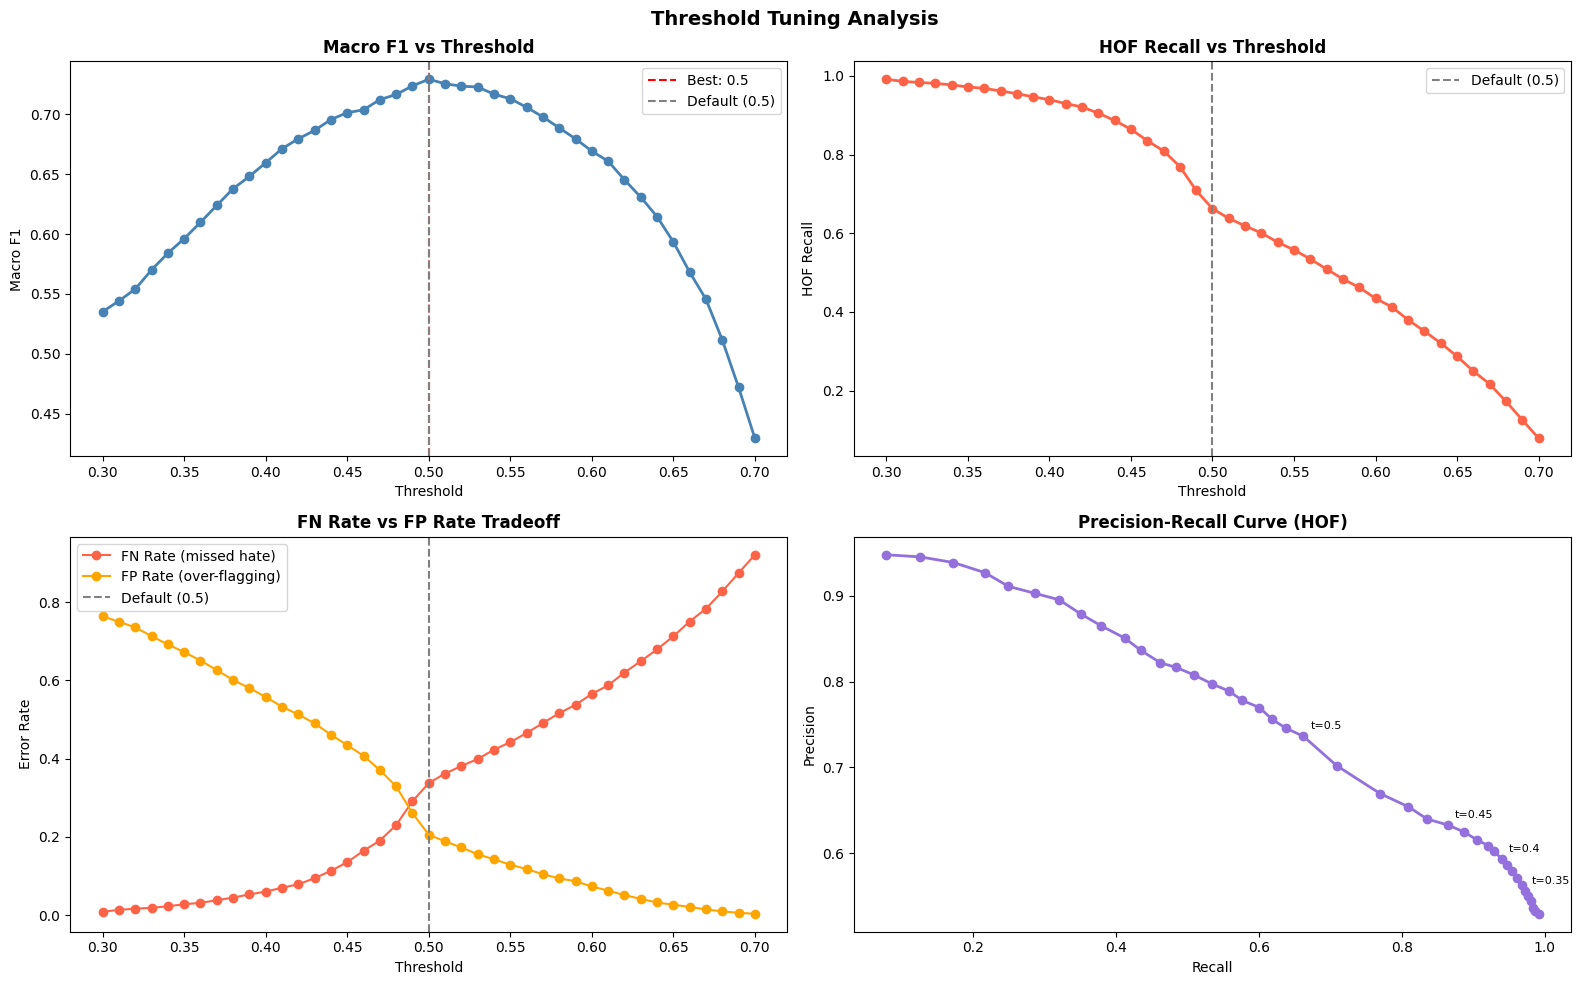

In [4]:
# Cell 4 — Precision-Recall tradeoff visualization

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Macro F1 vs threshold
axes[0][0].plot(results_df['threshold'], results_df['macro_f1'],
                'o-', color='steelblue', linewidth=2)
axes[0][0].axvline(x=best_macro['threshold'], color='red',
                   linestyle='--', label=f"Best: {best_macro['threshold']}")
axes[0][0].axvline(x=0.5, color='gray',
                   linestyle='--', label='Default (0.5)')
axes[0][0].set_title('Macro F1 vs Threshold', fontweight='bold')
axes[0][0].set_xlabel('Threshold')
axes[0][0].set_ylabel('Macro F1')
axes[0][0].legend()

# HOF Recall vs threshold
axes[0][1].plot(results_df['threshold'], results_df['hof_recall'],
                'o-', color='tomato', linewidth=2)
axes[0][1].axvline(x=0.5, color='gray', linestyle='--', label='Default (0.5)')
axes[0][1].set_title('HOF Recall vs Threshold', fontweight='bold')
axes[0][1].set_xlabel('Threshold')
axes[0][1].set_ylabel('HOF Recall')
axes[0][1].legend()

# FN Rate vs FP Rate (tradeoff)
axes[1][0].plot(results_df['threshold'], results_df['fn_rate'],
                'o-', color='tomato', label='FN Rate (missed hate)')
axes[1][0].plot(results_df['threshold'], results_df['fp_rate'],
                'o-', color='orange', label='FP Rate (over-flagging)')
axes[1][0].axvline(x=0.5, color='gray', linestyle='--', label='Default (0.5)')
axes[1][0].set_title('FN Rate vs FP Rate Tradeoff', fontweight='bold')
axes[1][0].set_xlabel('Threshold')
axes[1][0].set_ylabel('Error Rate')
axes[1][0].legend()

# Precision vs Recall
axes[1][1].plot(results_df['hof_recall'], results_df['hof_precision'],
                'o-', color='mediumpurple', linewidth=2)
axes[1][1].set_title('Precision-Recall Curve (HOF)', fontweight='bold')
axes[1][1].set_xlabel('Recall')
axes[1][1].set_ylabel('Precision')

# Annotate key thresholds
for t in [0.35, 0.40, 0.45, 0.50]:
    row = results_df[results_df['threshold']==t].iloc[0]
    axes[1][1].annotate(f't={t}',
        xy=(row['hof_recall'], row['hof_precision']),
        xytext=(5, 5), textcoords='offset points', fontsize=8)

plt.suptitle('Threshold Tuning Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

## Compare key thresholds:

In [5]:
# Cell 5 — Detailed comparison of key thresholds

key_thresholds = [0.35, 0.40, 0.45, 0.50]

print("="*70)
print("DETAILED COMPARISON — KEY THRESHOLDS")
print("="*70)

for t in key_thresholds:
    y_pred = (test_df['prob_HOF'] >= t).astype(int)
    print(f"\n{'='*35}")
    print(f"Threshold = {t}")
    print(f"{'='*35}")
    print(classification_report(
        y_true, y_pred,
        target_names=['NOT', 'HOF'],
        digits=4
    ))
    fn = ((y_pred==0) & (y_true==1)).sum()
    fp = ((y_pred==1) & (y_true==0)).sum()
    print(f"FN (missed hate) : {fn} ({fn/y_true.sum():.2%})")
    print(f"FP (over-flagged): {fp} ({fp/(y_true==0).sum():.2%})")

DETAILED COMPARISON — KEY THRESHOLDS

Threshold = 0.35
              precision    recall  f1-score   support

         NOT     0.9309    0.3277    0.4848      3164
         HOF     0.5562    0.9719    0.7075      2743

    accuracy                         0.6269      5907
   macro avg     0.7436    0.6498    0.5962      5907
weighted avg     0.7569    0.6269    0.5882      5907

FN (missed hate) : 77 (2.81%)
FP (over-flagged): 2127 (67.23%)

Threshold = 0.4
              precision    recall  f1-score   support

         NOT     0.8939    0.4422    0.5917      3164
         HOF     0.5935    0.9395    0.7275      2743

    accuracy                         0.6731      5907
   macro avg     0.7437    0.6908    0.6596      5907
weighted avg     0.7544    0.6731    0.6547      5907

FN (missed hate) : 166 (6.05%)
FP (over-flagged): 1765 (55.78%)

Threshold = 0.45
              precision    recall  f1-score   support

         NOT     0.8279    0.5654    0.6719      3164
         HOF     0.6

## Save optimal threshold:

In [6]:
# Cell 6 — Save results + optimal threshold

# Pick threshold that balances FN reduction without killing precision
# Usually t=0.40 is the sweet spot for content moderation
OPTIMAL_THRESHOLD = best_macro['threshold']

print("="*50)
print("📊 THRESHOLD TUNING SUMMARY")
print("="*50)
print(f"\nOriginal threshold : 0.50")
print(f"Optimal threshold  : {OPTIMAL_THRESHOLD}")
print(f"\nAt threshold={OPTIMAL_THRESHOLD}:")
opt_row = results_df[results_df['threshold']==OPTIMAL_THRESHOLD].iloc[0]
print(f"  Macro F1     : {opt_row['macro_f1']}")
print(f"  HOF Recall   : {opt_row['hof_recall']}")
print(f"  FN Rate      : {opt_row['fn_rate']:.2%}")
print(f"  FP Rate      : {opt_row['fp_rate']:.2%}")

print(f"\nAt original threshold=0.50:")
print(f"  Macro F1     : {orig['macro_f1']}")
print(f"  HOF Recall   : {orig['hof_recall']}")
print(f"  FN Rate      : {orig['fn_rate']:.2%}")
print(f"  FP Rate      : {orig['fp_rate']:.2%}")

fn_reduction = (orig['fn_rate'] - opt_row['fn_rate']) / orig['fn_rate'] * 100
print(f"\n✅ FN Rate reduced by {fn_reduction:.1f}%!")

results_df.to_csv('/kaggle/working/threshold_results.csv', index=False)
print("\n✅ Saved threshold_results.csv")

📊 THRESHOLD TUNING SUMMARY

Original threshold : 0.50
Optimal threshold  : 0.5

At threshold=0.5:
  Macro F1     : 0.7293
  HOF Recall   : 0.6624
  FN Rate      : 33.76%
  FP Rate      : 20.58%

At original threshold=0.50:
  Macro F1     : 0.7293
  HOF Recall   : 0.6624
  FN Rate      : 33.76%
  FP Rate      : 20.58%

✅ FN Rate reduced by 0.0%!

✅ Saved threshold_results.csv
